# 00 — Data Exploration

Understand the raw data before building features.
- `survey.csv`: 5,027 respondents, demographics + privacy opinions
- `amazon-purchases.csv`: 1.85M transactions linked via `Survey ResponseID`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('../amazon_ecom')
sns.set_theme(style='whitegrid')
%matplotlib inline

## Survey data

In [2]:
survey = pd.read_csv(DATA_DIR / 'survey.csv')
print(f'Shape: {survey.shape}')
survey.head(3)

Shape: (5027, 23)


,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,Q-sexual-orientation,Q-demos-state,Q-amazon-use-howmany,...,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,Q-life-changes,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes


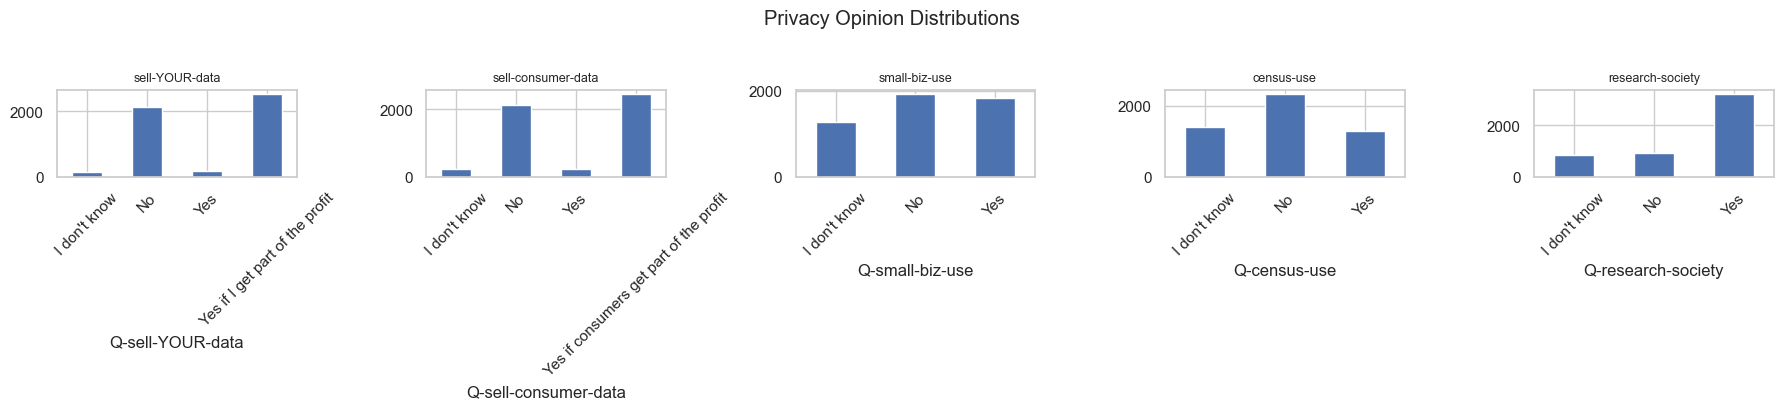

In [3]:
# Privacy opinion columns
opinion_cols = ['Q-sell-YOUR-data', 'Q-sell-consumer-data', 'Q-small-biz-use',
                'Q-census-use', 'Q-research-society']

fig, axes = plt.subplots(1, len(opinion_cols), figsize=(18, 4))
for ax, col in zip(axes, opinion_cols):
    survey[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col.replace('Q-', ''), fontsize=9)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Privacy Opinion Distributions', y=1.02)
plt.tight_layout()
plt.show()

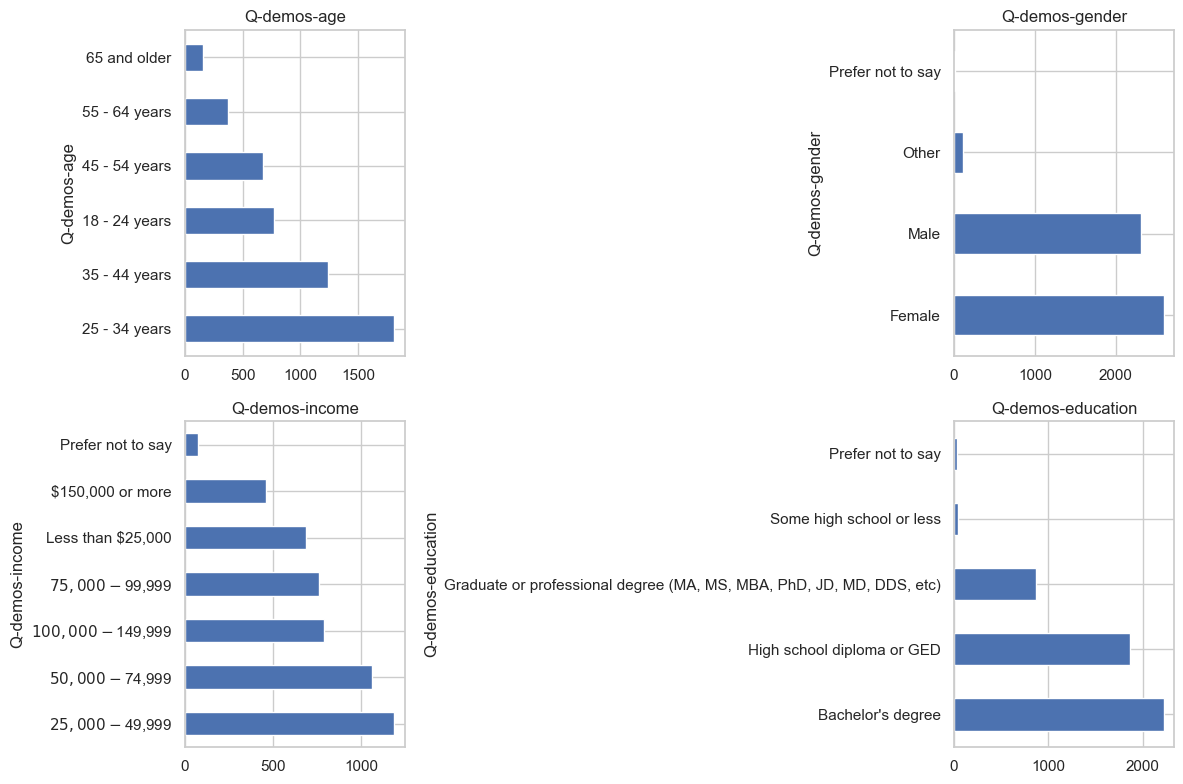

In [4]:
# Demographics overview
demo_cols = ['Q-demos-age', 'Q-demos-gender', 'Q-demos-income', 'Q-demos-education']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, demo_cols):
    survey[col].value_counts().plot(kind='barh', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Purchase data

In [5]:
# Load a sample first to understand structure (full file is 299 MB)
purchases_sample = pd.read_csv(DATA_DIR / 'amazon-purchases.csv', nrows=50_000,
                               parse_dates=['Order Date'])
print(f'Columns: {list(purchases_sample.columns)}')
print(f'Shape (sample): {purchases_sample.shape}')
purchases_sample.head(3)

Columns: ['Order Date', 'Purchase Price Per Unit', 'Quantity', 'Shipping Address State', 'Title', 'ASIN/ISBN (Product Code)', 'Category', 'Survey ResponseID']
Shape (sample): (50000, 8)


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF


In [6]:
# Load full dataset
purchases = pd.read_csv(DATA_DIR / 'amazon-purchases.csv', parse_dates=['Order Date'])
asin_col = 'ASIN/ISBN (Product Code)' if 'ASIN/ISBN (Product Code)' in purchases.columns else 'ASIN/ISBN'
print(f'Full shape: {purchases.shape}')
print(f'Date range: {purchases["Order Date"].min()} — {purchases["Order Date"].max()}')
print(f'Unique customers: {purchases["Survey ResponseID"].nunique():,}')
print(f'Unique ASINs:     {purchases[asin_col].nunique():,}')
print(f'Unique categories: {purchases["Category"].nunique():,}')

Full shape: (1850717, 8)
Date range: 2018-01-01 00:00:00 — 2024-08-15 00:00:00
Unique customers: 5,027
Unique ASINs:     939,082
Unique categories: 1,871


count    5027.000000
mean      368.155361
std       426.407538
min         1.000000
25%        92.000000
50%       232.000000
75%       489.000000
max      5415.000000
dtype: float64


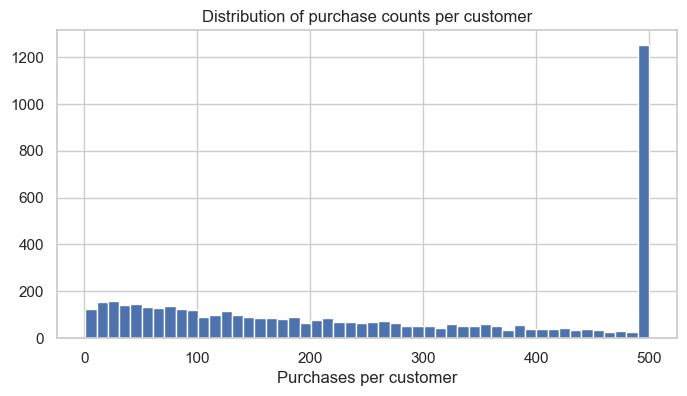

In [7]:
# Purchases per customer distribution
per_cust = purchases.groupby('Survey ResponseID').size()
print(per_cust.describe())
per_cust.clip(upper=500).hist(bins=50, figsize=(8,4))
plt.xlabel('Purchases per customer')
plt.title('Distribution of purchase counts per customer')
plt.show()

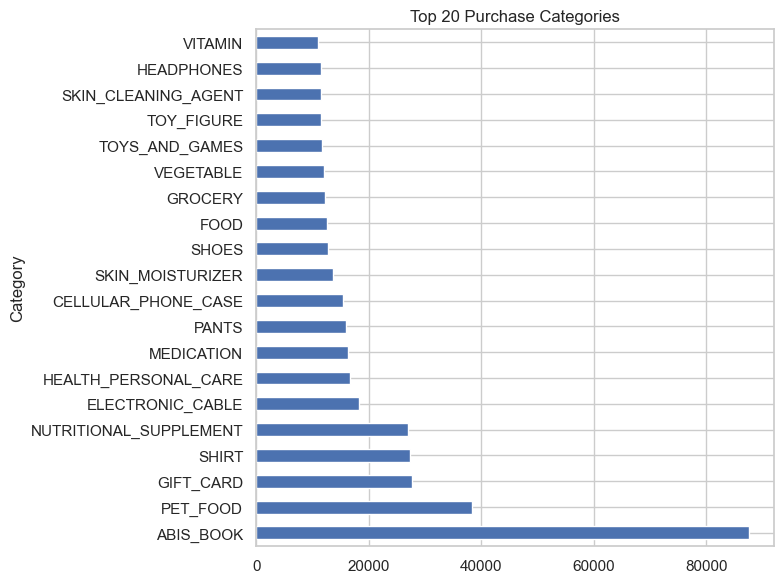

In [8]:
# Top categories
top_cats = purchases['Category'].value_counts().head(20)
top_cats.plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 Purchase Categories')
plt.tight_layout()
plt.show()

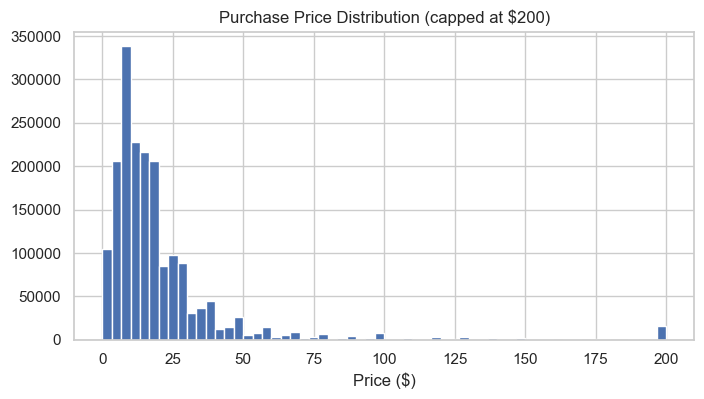

In [9]:
# Price distribution (clip outliers)
purchases['Purchase Price Per Unit'] = pd.to_numeric(
    purchases['Purchase Price Per Unit'], errors='coerce')
purchases['Purchase Price Per Unit'].clip(upper=200).dropna().hist(bins=60, figsize=(8,4))
plt.xlabel('Price ($)')
plt.title('Purchase Price Distribution (capped at $200)')
plt.show()

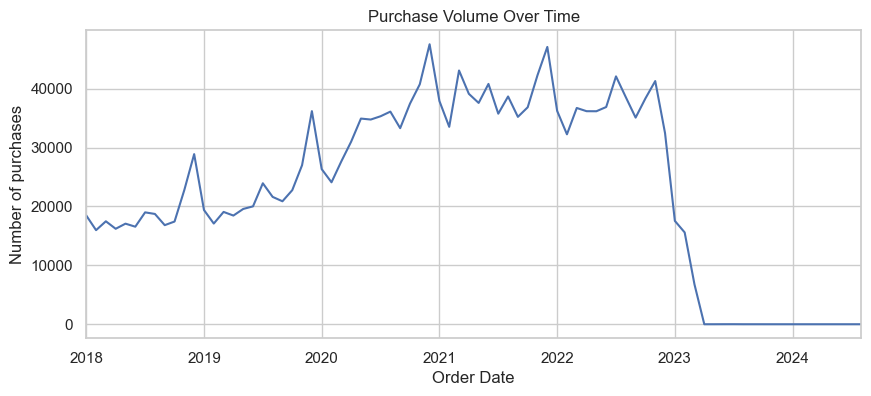

In [10]:
# Monthly purchase volume
purchases.set_index('Order Date').resample('ME').size().plot(figsize=(10,4))
plt.ylabel('Number of purchases')
plt.title('Purchase Volume Over Time')
plt.show()

In [11]:
# Repeat purchase rate
repeat_rate = purchases.duplicated(subset=['Survey ResponseID', asin_col]).mean()
print(f'Repeat purchase rate (same customer × ASIN): {repeat_rate:.1%}')

Repeat purchase rate (same customer × ASIN): 16.2%
